<a href="https://colab.research.google.com/github/mvaraujo1977/Cancer-Mama-Machine-Learning/blob/main/Cancer_de_Mama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diagnóstico de Câncer de Mama com Machine Learning

In [60]:
# ============================================================
# TECH CHALLENGE - FASE 1
# Diagnóstico de câncer de mama com Machine Learning
# Versão simplificada com colunas mais relevantes
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ============================================================
# 1) CARREGAR DATASET
# ============================================================
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

In [61]:
# ============================================================
# 2) RENOMEAR COLUNAS PARA PORTUGUÊS
# ============================================================
mapa_colunas = {
    "mean radius": "raio_medio",
    "mean texture": "textura_media",
    "mean perimeter": "perimetro_medio",
    "mean area": "area_media",
    "mean smoothness": "suavidade_media",
    "mean compactness": "compacidade_media",
    "mean concavity": "concavidade_media",
    "mean concave points": "pontos_concavos_medios",
    "mean symmetry": "simetria_media",
    "mean fractal dimension": "dimensao_fractal_media",

    "radius error": "erro_raio",
    "texture error": "erro_textura",
    "perimeter error": "erro_perimetro",
    "area error": "erro_area",
    "smoothness error": "erro_suavidade",
    "compactness error": "erro_compacidade",
    "concavity error": "erro_concavidade",
    "concave points error": "erro_pontos_concavos",
    "symmetry error": "erro_simetria",
    "fractal dimension error": "erro_dimensao_fractal",

    "worst radius": "pior_raio",
    "worst texture": "pior_textura",
    "worst perimeter": "pior_perimetro",
    "worst area": "pior_area",
    "worst smoothness": "pior_suavidade",
    "worst compactness": "pior_compacidade",
    "worst concavity": "pior_concavidade",
    "worst concave points": "pior_pontos_concavos",
    "worst symmetry": "pior_simetria",
    "worst fractal dimension": "pior_dimensao_fractal"
}

df = df.rename(columns=mapa_colunas)

In [62]:
# ============================================================
# 3) AJUSTAR TARGET
# ============================================================
# Original:
# 0 = malignant
# 1 = benign
#
# Novo:
# 1 = malignant
# 0 = benign
df["target_original"] = data.target
df["target"] = df["target_original"].map({0: 1, 1: 0})
df["diagnosis"] = df["target"].map({1: "malignant", 0: "benign"})

print("Dimensões do dataset:", df.shape)
print("\nPrimeiras linhas:")
print(df.head())

Dimensões do dataset: (569, 33)

Primeiras linhas:
   raio_medio  textura_media  perimetro_medio  area_media  suavidade_media  \
0       17.99          10.38           122.80      1001.0          0.11840   
1       20.57          17.77           132.90      1326.0          0.08474   
2       19.69          21.25           130.00      1203.0          0.10960   
3       11.42          20.38            77.58       386.1          0.14250   
4       20.29          14.34           135.10      1297.0          0.10030   

   compacidade_media  concavidade_media  pontos_concavos_medios  \
0            0.27760             0.3001                 0.14710   
1            0.07864             0.0869                 0.07017   
2            0.15990             0.1974                 0.12790   
3            0.28390             0.2414                 0.10520   
4            0.13280             0.1980                 0.10430   

   simetria_media  dimensao_fractal_media  ...  pior_area  pior_suavidade  \


In [63]:
# ============================================================
# 4) SELECIONAR APENAS AS COLUNAS MAIS RELEVANTES
# ============================================================
colunas_relevantes = [
    "raio_medio",
    "area_media",
    "concavidade_media",
    "pontos_concavos_medios",
    "pior_raio",
    "pior_perimetro",
    "pior_area",
    "pior_pontos_concavos"
]

print("\nColunas selecionadas para o modelo:")
for coluna in colunas_relevantes:
    print("-", coluna)

X = df[colunas_relevantes]
y = df["target"]


Colunas selecionadas para o modelo:
- raio_medio
- area_media
- concavidade_media
- pontos_concavos_medios
- pior_raio
- pior_perimetro
- pior_area
- pior_pontos_concavos


In [64]:
# ============================================================
# 5) DIVIDIR TREINO E TESTE
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTamanho treino:", X_train.shape)
print("Tamanho teste :", X_test.shape)


Tamanho treino: (455, 8)
Tamanho teste : (114, 8)


In [65]:
# ============================================================
# 6) PRÉ-PROCESSAMENTO
# ============================================================
colunas_numericas = X.columns.tolist()

preprocessador_com_escala = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas)
    ]
)

preprocessador_sem_escala = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), colunas_numericas)
    ]
)

In [66]:
# ============================================================
# 7) FUNÇÃO DE AVALIAÇÃO
# ============================================================
def avaliar_modelo(nome, modelo, X_teste, y_teste):
    y_pred = modelo.predict(X_teste)
    y_prob = modelo.predict_proba(X_teste)[:, 1]

    resultados = {
        "Modelo": nome,
        "Recall": recall_score(y_teste, y_pred, zero_division=0),
        "F1-score": f1_score(y_teste, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_teste, y_prob),
        "Precision": precision_score(y_teste, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_teste, y_pred)
    }

    print(f"\n================ {nome.upper()} ================")
    print(f"Recall   : {resultados['Recall']:.4f}  <-- principal")
    print(f"F1-score : {resultados['F1-score']:.4f}")
    print(f"ROC AUC  : {resultados['ROC AUC']:.4f}")
    print(f"Precision: {resultados['Precision']:.4f}")
    print(f"Accuracy : {resultados['Accuracy']:.4f} (somente informativa)")

    print("\nRelatório de classificação:")
    print(classification_report(
        y_teste,
        y_pred,
        target_names=["benign", "malignant"],
        zero_division=0
    ))

    cm = confusion_matrix(y_teste, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["benign", "malignant"],
        yticklabels=["benign", "malignant"]
    )
    plt.title(f"Matriz de confusão - {nome}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

    return resultados


================ REGRESSÃO LOGÍSTICA ================
Recall   : 0.9286  <-- principal
F1-score : 0.9512
ROC AUC  : 0.9974
Precision: 0.9750
Accuracy : 0.9649 (somente informativa)

Relatório de classificação:
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        72
   malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



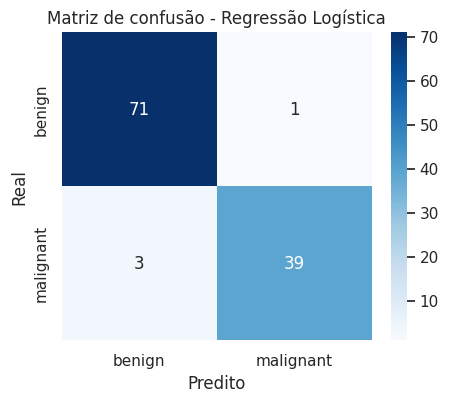

In [67]:
# ============================================================
# 8) MODELO 1 - REGRESSÃO LOGÍSTICA
# ============================================================
modelo_log = Pipeline(steps=[
    ("preprocessador", preprocessador_com_escala),
    ("classificador", LogisticRegression(max_iter=2000, random_state=42))
])

modelo_log.fit(X_train, y_train)
resultado_log = avaliar_modelo("Regressão Logística", modelo_log, X_test, y_test)


================ RANDOM FOREST ================
Recall   : 0.8810  <-- principal
F1-score : 0.9367
ROC AUC  : 0.9912
Precision: 1.0000
Accuracy : 0.9561 (somente informativa)

Relatório de classificação:
              precision    recall  f1-score   support

      benign       0.94      1.00      0.97        72
   malignant       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



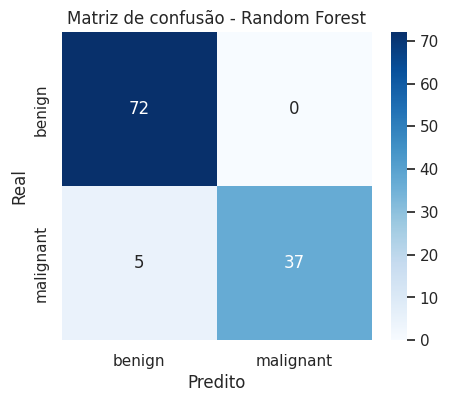

In [68]:
# ============================================================
# 9) MODELO 2 - RANDOM FOREST
# ============================================================

modelo_rf = Pipeline(steps=[
    ("preprocessador", preprocessador_sem_escala),
    ("classificador", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

modelo_rf.fit(X_train, y_train)
resultado_rf = avaliar_modelo("Random Forest", modelo_rf, X_test, y_test)

In [69]:
# ============================================================
# 10) COMPARAÇÃO DOS MODELOS
# ============================================================
ranking = pd.DataFrame([resultado_log, resultado_rf])

ranking = ranking.sort_values(
    by=["Recall", "F1-score", "ROC AUC"],
    ascending=False
).reset_index(drop=True)

ranking.index = ranking.index + 1

print("\n================ COMPARAÇÃO FINAL DOS MODELOS ================")
print("Critério de comparação:")
print("1º Recall")
print("2º F1-score")
print("3º ROC AUC")
print("\nRanking final:")
print(ranking[["Modelo", "Recall", "F1-score", "ROC AUC", "Precision", "Accuracy"]])

melhor_modelo = ranking.iloc[0]["Modelo"]
print(f"\nMelhor modelo selecionado: {melhor_modelo}")


================ COMPARAÇÃO FINAL DOS MODELOS ================
Critério de comparação:
1º Recall
2º F1-score
3º ROC AUC

Ranking final:
                Modelo    Recall  F1-score   ROC AUC  Precision  Accuracy
1  Regressão Logística  0.928571  0.951220  0.997354      0.975  0.964912
2        Random Forest  0.880952  0.936709  0.991237      1.000  0.956140

Melhor modelo selecionado: Regressão Logística


In [70]:
# ============================================================
# 11) EXEMPLO DE PREVISÃO
# ============================================================
paciente_exemplo = X_test.iloc[[0]]

pred = modelo_rf.predict(paciente_exemplo)[0]
prob = modelo_rf.predict_proba(paciente_exemplo)[0]

classes = {0: "benign", 1: "malignant"}

print("Dados do paciente:")
print(paciente_exemplo)

print("\nClasse prevista:", classes[pred])
print("Probabilidades [benign, malignant]:", prob)

Dados do paciente:
     raio_medio  area_media  concavidade_media  pontos_concavos_medios  \
120       11.41       403.3            0.03512                 0.02623   

     pior_raio  pior_perimetro  pior_area  pior_pontos_concavos  
120      12.82           83.74      510.5               0.08958  

Classe prevista: benign
Probabilidades [benign, malignant]: [1. 0.]


#TECH CHALLENGE - FASE 2

In [79]:
# ============================================================
# 12) FASE 2 - ALGORITMO GENÉTICO PARA OTIMIZAÇÃO DO RANDOM FOREST
# ============================================================

import random
import time
import numpy as np

from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.metrics import make_scorer, confusion_matrix

def specificity_score(y_true, y_pred):
    matriz = confusion_matrix(y_true, y_pred)

    tn = matriz[0, 0]
    fp = matriz[0, 1]

    return tn / (tn + fp)

In [80]:
# ============================================================
# 13) CONFIGURAÇÃO DO ALGORITMO GENÉTICO
# ============================================================

fitness_cache = {}

espaco_hiperparametros = {
    "n_estimators": [30, 50, 100, 200, 300, 400, 500],
    "max_depth": [3, 5, 10, 15, 20, None],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"]
}

In [81]:
# ============================================================
# 14) REPRESENTAÇÃO DOS INDIVÍDUOS
# ============================================================

def criar_individuo():
    return {
        "n_estimators": random.choice(espaco_hiperparametros["n_estimators"]),
        "max_depth": random.choice(espaco_hiperparametros["max_depth"]),
        "min_samples_split": random.choice(espaco_hiperparametros["min_samples_split"]),
        "min_samples_leaf": random.choice(espaco_hiperparametros["min_samples_leaf"]),
        "max_features": random.choice(espaco_hiperparametros["max_features"]),
        "criterion": random.choice(espaco_hiperparametros["criterion"]),
        "class_weight": random.choice(espaco_hiperparametros["class_weight"])
    }


def chave_individuo(individuo):
    return (
        individuo["n_estimators"],
        individuo["max_depth"],
        individuo["min_samples_split"],
        individuo["min_samples_leaf"],
        individuo["max_features"],
        individuo["criterion"],
        individuo["class_weight"]
    )

In [82]:
# ============================================================
# 15) FUNÇÃO FITNESS
# ============================================================

def calcular_fitness(individuo):

    chave = chave_individuo(individuo)

    if chave in fitness_cache:
        metricas = fitness_cache[chave]

        individuo["fitness"] = metricas["fitness"]
        individuo["accuracy"] = metricas["accuracy"]
        individuo["precision"] = metricas["precision"]
        individuo["recall"] = metricas["recall"]
        individuo["specificity"] = metricas["specificity"]
        individuo["roc_auc"] = metricas["roc_auc"]

        return metricas["fitness"]

    modelo = Pipeline(steps=[
        ("preprocessador", preprocessador_sem_escala),
        ("classificador", RandomForestClassifier(
            n_estimators=individuo["n_estimators"],
            max_depth=individuo["max_depth"],
            min_samples_split=individuo["min_samples_split"],
            min_samples_leaf=individuo["min_samples_leaf"],
            max_features=individuo["max_features"],
            criterion=individuo["criterion"],
            class_weight=individuo["class_weight"],
            random_state=42,
            n_jobs=-1
        ))
    ])

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }

    resultados = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=3,
        scoring=scoring,
        n_jobs=-1
    )

    accuracy = resultados["test_accuracy"].mean()
    precision = resultados["test_precision"].mean()
    recall = resultados["test_recall"].mean()
    f1 = resultados["test_f1"].mean()
    roc_auc = resultados["test_roc_auc"].mean()

    specificity_scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=3,
        scoring=make_scorer(specificity_score),
        n_jobs=-1
    )

    specificity = specificity_scores.mean()

    # Aqui você escolhe qual métrica o algoritmo genético vai otimizar.
    # Para problema médico, faz sentido otimizar recall.
    fitness = recall

    individuo["fitness"] = fitness
    individuo["accuracy"] = accuracy
    individuo["precision"] = precision
    individuo["recall"] = recall
    individuo["specificity"] = specificity
    individuo["roc_auc"] = roc_auc

    fitness_cache[chave] = {
        "fitness": fitness,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "roc_auc": roc_auc
    }

    return fitness

In [83]:
# ============================================================
# 16) OPERADORES GENÉTICOS
# ============================================================

def selecionar_por_torneio(populacao, tamanho_torneio=3):

    competidores = random.sample(populacao, tamanho_torneio)

    competidores = sorted(
        competidores,
        key=lambda ind: ind["fitness"],
        reverse=True
    )

    return competidores[0]


def crossover(pai, mae):

    filho = {}

    for gene in espaco_hiperparametros.keys():
        filho[gene] = random.choice([pai[gene], mae[gene]])

    return filho


def mutacao(individuo, taxa_mutacao):

    novo = individuo.copy()

    novo.pop("fitness", None)

    for gene in espaco_hiperparametros.keys():

        if random.random() < taxa_mutacao:

            novo[gene] = random.choice(espaco_hiperparametros[gene])

    return novo

In [84]:
# ============================================================
# 17) EXECUÇÃO DO ALGORITMO GENÉTICO
# ============================================================

def executar_algoritmo_genetico(
    tamanho_populacao=20,
    numero_geracoes=10,
    taxa_mutacao=0.2,
    percentual_elite=0.1
):

    inicio = time.time()

    populacao = []

    for _ in range(tamanho_populacao):

        individuo = criar_individuo()
        individuo["fitness"] = calcular_fitness(individuo)

        populacao.append(individuo)

    historico = []

    melhor_global = None

    for geracao in range(1, numero_geracoes + 1):

        populacao = sorted(
            populacao,
            key=lambda ind: ind["fitness"],
            reverse=True
        )

        melhor = populacao[0]

        lista_fitness = [i["fitness"] for i in populacao]

        media = np.mean(lista_fitness)
        pior = np.min(lista_fitness)
        desvio = np.std(lista_fitness)

        if melhor_global is None or melhor["fitness"] > melhor_global["fitness"]:
            melhor_global = melhor.copy()

        historico.append({
            "geracao": geracao,
            "melhor_fitness": melhor["fitness"],
            "media_fitness": media,
            "pior_fitness": pior,
            "desvio_fitness": desvio,

            "accuracy": melhor.get("accuracy"),
            "precision": melhor.get("precision"),
            "recall": melhor.get("recall"),
            "specificity": melhor.get("specificity"),
            "roc_auc": melhor.get("roc_auc"),

            "melhor_individuo": melhor.copy()
        })

        print(
            f"Geração {geracao:02d} | "
            f"Melhor F1 = {melhor['fitness']:.4f} | "
            f"Acc = {melhor.get('accuracy', 0):.4f} | "
            f"Prec = {melhor.get('precision', 0):.4f} | "
            f"Recall = {melhor.get('recall', 0):.4f} | "
            f"Esp = {melhor.get('specificity', 0):.4f} | "
            f"AUC = {melhor.get('roc_auc', 0):.4f} | "
            f"Média F1 = {media:.4f} | "
            f"Pior F1 = {pior:.4f} | "
            f"Desvio = {desvio:.4f}"
        )

        quantidade_elite = max(
            1,
            int(tamanho_populacao * percentual_elite)
        )

        nova_populacao = [
            ind.copy()
            for ind in populacao[:quantidade_elite]
        ]

        while len(nova_populacao) < tamanho_populacao:

            pai = selecionar_por_torneio(populacao)
            mae = selecionar_por_torneio(populacao)

            filho = crossover(pai, mae)

            filho = mutacao(
                filho,
                taxa_mutacao
            )

            filho["fitness"] = calcular_fitness(filho)

            nova_populacao.append(filho)

        populacao = nova_populacao

    melhor_final = sorted(
        populacao,
        key=lambda ind: ind["fitness"],
        reverse=True
    )[0]

    fim = time.time()

    return {
        "melhor_individuo": melhor_global if melhor_global is not None else melhor_final,
        "melhor_final_ultima_populacao": melhor_final,
        "historico": historico,
        "tempo_execucao": fim - inicio
    }

In [85]:
# ============================================================
# 18) EXPERIMENTO 1 - ALGORITMO GENÉTICO
# ============================================================

resultado_exp1 = executar_algoritmo_genetico(
    tamanho_populacao=12,
    numero_geracoes=8,
    taxa_mutacao=0.20,
    percentual_elite=0.10
)

print("\n================ RESULTADO DO EXPERIMENTO 1 ================")
print("Configuração:")
print("População: 12")
print("Gerações: 8")
print("Taxa de mutação: 20%")
print("Elite: 10%")

print("\nMelhor indivíduo encontrado:")
print(resultado_exp1["melhor_individuo"])

print(f"\nTempo de execução: {resultado_exp1['tempo_execucao']:.2f} segundos")

Geração 01 | Melhor F1 = 0.9353 | Acc = 0.9406 | Prec = 0.9108 | Recall = 0.9353 | Esp = 0.9439 | AUC = 0.9810 | Média F1 = 0.9148 | Pior F1 = 0.9002 | Desvio = 0.0130
Geração 02 | Melhor F1 = 0.9353 | Acc = 0.9406 | Prec = 0.9108 | Recall = 0.9353 | Esp = 0.9439 | AUC = 0.9810 | Média F1 = 0.9284 | Pior F1 = 0.9177 | Desvio = 0.0047
Geração 03 | Melhor F1 = 0.9353 | Acc = 0.9406 | Prec = 0.9108 | Recall = 0.9353 | Esp = 0.9439 | AUC = 0.9810 | Média F1 = 0.9294 | Pior F1 = 0.9060 | Desvio = 0.0079
Geração 04 | Melhor F1 = 0.9353 | Acc = 0.9406 | Prec = 0.9108 | Recall = 0.9353 | Esp = 0.9439 | AUC = 0.9810 | Média F1 = 0.9279 | Pior F1 = 0.9177 | Desvio = 0.0054
Geração 05 | Melhor F1 = 0.9353 | Acc = 0.9406 | Prec = 0.9108 | Recall = 0.9353 | Esp = 0.9439 | AUC = 0.9810 | Média F1 = 0.9284 | Pior F1 = 0.9119 | Desvio = 0.0071
Geração 06 | Melhor F1 = 0.9353 | Acc = 0.9406 | Prec = 0.9108 | Recall = 0.9353 | Esp = 0.9439 | AUC = 0.9810 | Média F1 = 0.9236 | Pior F1 = 0.9001 | Desvio =

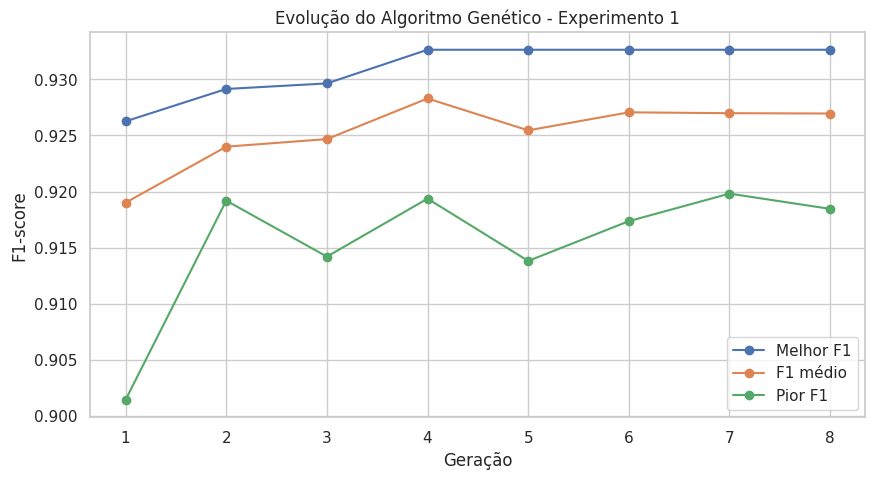

In [58]:
# ============================================================
# 19) GRÁFICO DE EVOLUÇÃO - EXPERIMENTO 1
# ============================================================

historico_exp1 = pd.DataFrame(resultado_exp1["historico"])

plt.figure(figsize=(10, 5))
plt.plot(historico_exp1["geracao"], historico_exp1["melhor_fitness"], marker="o", label="Melhor Recall")
plt.plot(historico_exp1["geracao"], historico_exp1["media_fitness"], marker="o", label="Recall médio")
plt.plot(historico_exp1["geracao"], historico_exp1["pior_fitness"], marker="o", label="Pior Recall")

plt.title("Evolução do Algoritmo Genético - Experimento 1")
plt.xlabel("Geração")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)
plt.show()